# Optimization & visualization of the electron density

### import basic stuff

In [8]:
import numpy as np

In [9]:
import sys
import os
from equiv_dens.training.grids import CubicalGrid
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### import local dftpy module (optional)

In [10]:
#sys.path.append('/home/sxc/work/dftpy/dftpy/src/')
#sys.path.append('/Users/michele/Box/devel/dftpy_2/src/')
#data = '/home/sxc/work/dftpy/dftpy/examples/DATA/'
data = '/home/mihail/Documents/workspace/dftpy/examples/DATA/'

In [13]:
from dftpy.field import *
from dftpy.grid import *
from dftpy.functionals import FunctionalClass, TotalEnergyAndPotential
from dftpy.pseudo import LocalPseudo
from dftpy.formats import io
from dftpy.math_utils import bestFFTsize
from dftpy.time_data import TimeData
from dftpy.optimization import Optimization
from dftpy.constants import LEN_CONV, ENERGY_CONV
from dftpy.system import System

Use "numpy" for Fourier Transform


### simple functions to make a grid and initial guess

In [14]:
def MakeGrid(metric,gap):
    nr = np.zeros(3, dtype = 'int32')
    for i in range(3):
        nr[i] = int(np.sqrt(metric[i, i])/gap)
    print('The initial grid size is ', nr)
    for i in range(3):
        nr[i] = bestFFTsize(nr[i])
    print('The final grid size is ', nr)
    grid = DirectGrid(lattice=lattice, nr=nr, units=None, full=False)
    return grid

def guess_rho(grid,ions):
    charge_total = 0.0
    zerosA = np.zeros(grid.nnr, dtype=float)
    rho_ini = DirectField(grid=grid, griddata_F=zerosA, rank=1)
    for i in range(ions.nat) :
        charge_total += ions.Zval[ions.labels[i]]
    rho_ini[:] = charge_total/ions.pos.cell.volume
    return rho_ini

### read input, set pseudo files, and make a grid

In [15]:
path_pp=data
path_pos=data
file1='Al_lda.oe01.recpot'
posfile='fcc.vasp'
ions = io.read(path_pos+posfile, names=['Al'])
lattice = ions.pos.cell.lattice
metric = np.dot(lattice.T, lattice)

gap = 0.4
grid = MakeGrid(metric,gap)

The initial grid size is  [19 19 19]
The final grid size is  [20 20 20]


### read pseudo file, generate local pseudo, and generate guess density

In [16]:
PP_list = {'Al': path_pp+file1}
PSEUDO = LocalPseudo(grid = grid, ions=ions,PP_list=PP_list,PME=True)

rho_ini = guess_rho(grid,ions)

setting key: Al
Recpot pseudopotential /home/mihail/Documents/workspace/dftpy/examples/DATA/Al_lda.oe01.recpot loaded


### instance KEDF, XC and HARTREE functionals

In [17]:
optional_kwargs = {}
KE = FunctionalClass(type='KEDF',name='x_TF_y_vW',optional_kwargs=optional_kwargs)
XC = FunctionalClass(type='XC',name='LDA')
HARTREE = FunctionalClass(type='HARTREE')

### instance DFTpy energy evaluator

In [18]:
E_v_Evaluator = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)

### instance and execute DFTpy density optimizer

In [19]:
optimization_options = {\
        'econv' : 1e-6, # Energy Convergence (a.u./atom)
        'maxfun' : 50,  # For TN method, it's the max steps for searching direction
        'maxiter' : 100,# The max steps for optimization
        }
optimization_options["econv"] *= ions.nat
opt = Optimization(EnergyEvaluator=E_v_Evaluator, optimization_options = optimization_options,
        optimization_method = 'TN')


new_rho = opt.optimize_rho(guess_rho=rho_ini)

evalfunctional KEDF
evalfunctional x_TF_y_vW
calc type ['E', 'V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed3756d8>
evalfunctional XC
evalfunctional LDA
calc type ['E', 'V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed86acf8>
evalfunctional HARTREE
evalfunctional HARTREE
calc type ['E', 'V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed3758d0>
evalfunctional PSEUDO
evalfunctional PSEUDO
calc type ['E', 'V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed375ac8>
Step    Energy(a.u.)            dE              dP              Nd      Nls     Time(s)         
0       2.692153778822E+00      2.692154E+00    7.877090E-01    1       1       4.669499E-02    
evalfunctional KEDF
evalfunctional x_TF_y_vW
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed375c18>
evalfunctional XC
evalfunctional LDA
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed375dd8>
evalfunctional HARTREE

energy <dftpy.functional_output.Functional object at 0x7fb4ed375828>
evalfunctional HARTREE
evalfunctional HARTREE
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ebf2de48>
evalfunctional PSEUDO
evalfunctional PSEUDO
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ebf2d8d0>
evalfunctional KEDF
evalfunctional x_TF_y_vW
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed3a6748>
evalfunctional XC
evalfunctional LDA
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed375dd8>
evalfunctional HARTREE
evalfunctional HARTREE
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed3759b0>
evalfunctional PSEUDO
evalfunctional PSEUDO
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed375cf8>
evalfunctional KEDF
evalfunctional x_TF_y_vW
calc type ['E', 'V']
energy <dftpy.functional_output.Functional object at 0x7fb4ebf3d470>
evalfunctional XC
evalfu

evalfunctional XC
evalfunctional LDA
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ebf2d390>
evalfunctional HARTREE
evalfunctional HARTREE
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ebf2d080>
evalfunctional PSEUDO
evalfunctional PSEUDO
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed3a65f8>
evalfunctional KEDF
evalfunctional x_TF_y_vW
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed375c88>
evalfunctional XC
evalfunctional LDA
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed375c50>
evalfunctional HARTREE
evalfunctional HARTREE
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed375c18>
evalfunctional PSEUDO
evalfunctional PSEUDO
calc type ['V']
energy <dftpy.functional_output.Functional object at 0x7fb4ed375940>
evalfunctional KEDF
evalfunctional x_TF_y_vW
calc type ['V']
energy <dftpy.functional_output.Functional ob

### evaluate final energy, make a mol system class, and print results

In [20]:
Enew = E_v_Evaluator.Energy(rho=new_rho, ions=ions, usePME = True)
mol = System(ions,cell=grid,name='test',field=new_rho)

print('Energy New (a.u.)', Enew)
print('Energy New (eV)', Enew * ENERGY_CONV['Hartree']['eV'])
print('Energy New (eV/atom)', Enew * ENERGY_CONV['Hartree']['eV']/ions.nat)
print('-' * 31, 'Time information', '-' * 31)
print("{:28s}{:24s}{:20s}".format('Label', 'Cost(s)', 'Number'))
for key in TimeData.cost :
    print("{:28s}{:<24.4f}{:<20d}".format(key, TimeData.cost[key], TimeData.number[key]))
print('-' * 80)

gmax 8.20967524687299
eta 0.7299999999999993
real_energy 0.0
corr_energy -18.04476711663282
rec_energy 7.2616358977233615
Ewald : -10.783131218909466
evalfunctional KEDF
evalfunctional x_TF_y_vW
calc type ['E']
energy <dftpy.functional_output.Functional object at 0x7fb4ebf3d2b0>
evalfunctional XC
evalfunctional LDA
calc type ['E']
energy <dftpy.functional_output.Functional object at 0x7fb4ebf3dac8>
evalfunctional HARTREE
evalfunctional HARTREE
calc type ['E']
energy <dftpy.functional_output.Functional object at 0x7fb4ebf3def0>
evalfunctional PSEUDO
evalfunctional PSEUDO
calc type ['E']
energy <dftpy.functional_output.Functional object at 0x7fb4ebf52080>
Energy New (a.u.) -8.281138759120598
Energy New (eV) -225.34124199416655
Energy New (eV/atom) -56.33531049854164
------------------------------- Time information -------------------------------
Label                       Cost(s)                 Number              
Optimize                    1.0134                  1                  

### Visualize with ipv

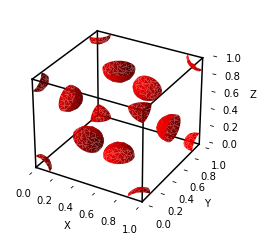

In [21]:
from dftpy.visualize.jupyter import view_density
view_density(mol)

In [22]:
from dftpy.visualize.vesta import view_on_vesta
view_on_vesta(mol)

OS is:  linux


In [24]:
en_calc = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)

print('energy new', en_calc.Energy(rho=new_rho, ions=ions, usePME=False))
print('energy init', en_calc.Energy(rho=rho_ini, ions=ions, usePME=False))

gmax 8.20967524687299
eta 0.7299999999999993
real_energy 0.0
corr_energy -18.04476711663282
rec_energy 7.2616358977233615
Ewald : -10.783131218909457
evalfunctional KEDF
evalfunctional x_TF_y_vW
calc type ['E']
energy 3.2486352546238275
evalfunctional XC
evalfunctional LDA
calc type ['E']
energy -3.1933129443291715
evalfunctional HARTREE
evalfunctional HARTREE
calc type ['E']
energy 0.006289339311555472
evalfunctional PSEUDO
evalfunctional PSEUDO
calc type ['E']
energy 2.4403808101826554
energy new -8.28113875912059
gmax 8.20967524687299
eta 0.7299999999999993
real_energy 0.0
corr_energy -18.04476711663282
rec_energy 7.2616358977233615
Ewald : -10.783131218909457
evalfunctional KEDF
evalfunctional x_TF_y_vW
calc type ['E']
energy 3.083161095941591
evalfunctional XC
evalfunctional LDA
calc type ['E']
energy -3.1835350094287844
evalfunctional HARTREE
evalfunctional HARTREE
calc type ['E']
energy -6.205546220008756e-35
evalfunctional PSEUDO
evalfunctional PSEUDO
calc type ['E']
energy 2.7

In [15]:
print(ions.labels)
print(rho_ini.grid.r.shape)
#print(grid.r)

print(rho_ini.grid.rr.shape)
rg = np.linspace(0, 7.65339081, 21)
print(rg)
X, Y, Z = np.meshgrid(rg, rg, rg, indexing='ij')
print(X.shape)

gr = np.stack([X, Y, Z], axis=0)
print('gr.shape' ,gr.shape)
#print(np.allclose(gr, grid.r))
#print(grid.r[:, 1, 0, 0])
#print(gr[:, 1, 0, 0])

['Al' 'Al' 'Al' 'Al']
(3, 20, 20, 20)
(20, 20, 20)
[0.         0.38266954 0.76533908 1.14800862 1.53067816 1.9133477
 2.29601724 2.67868678 3.06135632 3.44402586 3.82669541 4.20936495
 4.59203449 4.97470403 5.35737357 5.74004311 6.12271265 6.50538219
 6.88805173 7.27072127 7.65339081]
(21, 21, 21)
gr.shape (3, 21, 21, 21)


In [29]:
grid_cl = CubicalGrid(None, nx=20, ny=20, nz=20, origin=[0, 0, 0], extent=[7.65339081, 7.65339081, 7.65339081])

In [33]:
rg = np.linspace(0, 7.65339081, 21)
X, Y, Z = np.meshgrid(rg, rg, rg, indexing='ij')

gr = np.stack([X, Y, Z], axis=0)

print(grid.r.shape)
print(grid_cl.coords.shape)

lda = LDAFunctional([3, 3, 3, 3])
#print('rho ini', rho_ini)
rho = torch.tensor(new_rho)
#print('rho tensor', rho)
pos = torch.tensor(ions.pos)
gr = gr.reshape(3, -1).T
#gr = rho_ini.grid.r.reshape(3, -1).T
gr = torch.tensor(gr)
print(gr.shape)
lda(rho, grid_cl, pos, PSEUDO)

(3, 20, 20, 20)
torch.Size([8000, 3])
torch.Size([9261, 3])
real energy tensor(0., dtype=torch.float64)
corr energy -18.044767116114485
rec energy tensor(7.2616, dtype=torch.float64)
thomas fermi energy tensor(3.1088, dtype=torch.float64)
von weizsacker energy tensor(0.1399, dtype=torch.float64)
lda energy -3.193312946723912
hartree energy tensor(0.0063, dtype=torch.float64)
pseudo energy tensor(2.4404, dtype=torch.float64)


tensor(-8.2811, dtype=torch.float64)

In [18]:
rho_ini.shape

(20, 20, 20)

In [19]:
ions.pos.shape

(4, 3)

In [20]:
rec_grid = grid.get_reciprocal()
print(rec_grid.g)
print(grid.r)

[[[[ 0.          0.          0.         ...  0.          0.
     0.        ]
   [ 0.          0.          0.         ...  0.          0.
     0.        ]
   [ 0.          0.          0.         ...  0.          0.
     0.        ]
   ...
   [ 0.          0.          0.         ...  0.          0.
     0.        ]
   [ 0.          0.          0.         ...  0.          0.
     0.        ]
   [ 0.          0.          0.         ...  0.          0.
     0.        ]]

  [[ 0.82096752  0.82096752  0.82096752 ...  0.82096752  0.82096752
     0.82096752]
   [ 0.82096752  0.82096752  0.82096752 ...  0.82096752  0.82096752
     0.82096752]
   [ 0.82096752  0.82096752  0.82096752 ...  0.82096752  0.82096752
     0.82096752]
   ...
   [ 0.82096752  0.82096752  0.82096752 ...  0.82096752  0.82096752
     0.82096752]
   [ 0.82096752  0.82096752  0.82096752 ...  0.82096752  0.82096752
     0.82096752]
   [ 0.82096752  0.82096752  0.82096752 ...  0.82096752  0.82096752
     0.82096752]]

  [[ 1.641

In [21]:
gr = grid.r

nrR = gr.shape[1:]
print('nrR', nrR)
fac = 2 * np.pi
bg = fac * np.linalg.inv(grid.lattice)
reciprocal_lat = bg.T
print(reciprocal_lat)
print(rec_grid.lattice)
ax = []
for i in range(3):
    dd = 1 / nrR[i]
    if i == 2:
        ax.append(np.fft.rfftfreq(nrR[i], d=dd))
    else:
        freq = np.fft.fftfreq(nrR[i], d=dd)

        ax.append(freq)
S0, S1, S2 = np.meshgrid(ax[0], ax[1], ax[2], indexing="ij")

# S_cart = s2r(S, self)
# S_cart = np.asarray([S2, S1, S0])
S_cart = np.asarray([S0, S1, S2])
S_cart = np.einsum("j...,kj->k...", S_cart, reciprocal_lat)

print(rec_grid.g)
print(S_cart)
print(np.allclose(rec_grid.g, S_cart))

nrR (20, 20, 20)
[[0.82096752 0.         0.        ]
 [0.         0.82096752 0.        ]
 [0.         0.         0.82096752]]
[[0.82096752 0.         0.        ]
 [0.         0.82096752 0.        ]
 [0.         0.         0.82096752]]
[[[[ 0.          0.          0.         ...  0.          0.
     0.        ]
   [ 0.          0.          0.         ...  0.          0.
     0.        ]
   [ 0.          0.          0.         ...  0.          0.
     0.        ]
   ...
   [ 0.          0.          0.         ...  0.          0.
     0.        ]
   [ 0.          0.          0.         ...  0.          0.
     0.        ]
   [ 0.          0.          0.         ...  0.          0.
     0.        ]]

  [[ 0.82096752  0.82096752  0.82096752 ...  0.82096752  0.82096752
     0.82096752]
   [ 0.82096752  0.82096752  0.82096752 ...  0.82096752  0.82096752
     0.82096752]
   [ 0.82096752  0.82096752  0.82096752 ...  0.82096752  0.82096752
     0.82096752]
   ...
   [ 0.82096752  0.82096752  0.8

In [22]:
print(rho.ndim)

3


In [25]:
print(type(rho_ini))

<class 'dftpy.field.DirectField'>


In [44]:
0.3781536405194684**3

0.05407603708811198